# A4 – End-to-End Machine Learning for Predictive Maintenance  
## CRISP-ML Lifecycle Implementation (CMAPSS FD004)

**Business Objective:**  
Develop a decision-support model to identify turbomachinery units at high risk of near-term failure, supporting proactive maintenance planning in an energy infrastructure context.

**Approach:**  
- Supervised binary classification (near-failure vs normal)
- Logistic Regression (interpretable baseline)
- Random Forest (bagging ensemble)
- Gradient Boosting (boosting ensemble)
- Threshold optimisation aligned with business risk appetite

**Evaluation Focus:**  
Recall–precision trade-off, ROC-AUC, and decision-policy design rather than pure accuracy.


# 1. Setup and Imports

In [233]:
# ============================================================
# Imports & Global Configuration
# Purpose: Set up all libraries required for data handling,
#          visualisation, modeling, and evaluation in a
#          reproducible, assessment-friendly way.
# ============================================================

# -----------------------------
# Core data handling
# -----------------------------
import pandas as pd  # Provides DataFrame structures + IO tools (CSV reading, joins, groupby, etc.)
import numpy as np   # Provides fast numerical operations (arrays, math functions, vectorization)

# -----------------------------
# Visualisation (kept simple and interpretable)
# -----------------------------
import matplotlib.pyplot as plt  # Matplotlib is the standard plotting library used for clear, exam-friendly figures

# -----------------------------
# Modeling & evaluation (scikit-learn)
# -----------------------------
from sklearn.model_selection import train_test_split  # Splits data into train/validation sets for honest evaluation
from sklearn.preprocessing import StandardScaler      # Standardizes features (mean=0, std=1) for scale-sensitive models
from sklearn.pipeline import Pipeline                # Chains preprocessing + model steps into one reproducible workflow
from sklearn.linear_model import LogisticRegression  # Baseline classifier: interpretable, linear decision boundary in log-odds space
from sklearn.ensemble import RandomForestClassifier  # Ensemble of trees: captures non-linearities + interactions in sensor signals

from sklearn.metrics import (
    classification_report,  # Produces precision/recall/F1/support per class (useful for imbalanced settings)
    confusion_matrix,       # Shows TN/FP/FN/TP counts (translates model behavior into operational consequences)
    roc_auc_score,          # Computes ROC-AUC: measures ranking quality across all thresholds
    roc_curve               # Computes ROC curve points (FPR/TPR) for visualization and threshold analysis
)

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_STATE = 42  # Fixed seed ensures splits and stochastic models produce repeatable results across runs


### Helper Function for Visualisations

In [234]:
# ============================================================
# Helper Functions for Evaluation & Interpretability
# Purpose: Provide reusable plotting utilities so evaluation
#          outputs are consistent, readable, and business-interpretable.
# ============================================================

# -----------------------------
# Core libraries (numerics, tables, plots)
# -----------------------------
import numpy as np                 # Used for numerical operations (e.g., finding closest threshold index)
import pandas as pd                # Used for feature importance tables (DataFrame)
import matplotlib.pyplot as plt    # Used for all plots (kept simple and interpretable)

# -----------------------------
# Evaluation metrics used across models
# -----------------------------
from sklearn.metrics import (
    confusion_matrix,          # Converts predictions into TN/FP/FN/TP counts
    roc_curve,                 # Computes ROC curve points (FPR/TPR) across thresholds
    auc,                       # Computes area under ROC curve (AUC)
    precision_recall_curve     # Computes Precision-Recall curve points across thresholds
)

# ============================================================
# 1) Confusion Matrix Plot
# ============================================================
def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plot a 2x2 confusion matrix with clear class labels and readable annotations.
    Also prints TN/FP/FN/TP counts to make operational implications explicit.
    
    Parameters
    ----------
    y_true : array-like
        Ground-truth class labels (0=Normal, 1=Near-failure).
    y_pred : array-like
        Predicted class labels (0/1), typically derived from a probability threshold.
    title : str
        Plot title (use to specify model + threshold context).
    """
    # Import locally to keep this function portable in notebooks (works even if imports are reorganised)
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt
    
    # Compute confusion matrix:
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(y_true, y_pred)
    
    # Create a new figure for a clean, single-plot output (no subplots)
    plt.figure()
    plt.imshow(cm)  # Display the matrix as an image (heatmap-like)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    # Annotate each cell with the count (white text improves contrast on darker cells)
    for i in range(cm.shape[0]):            # Loop over true classes (rows)
        for j in range(cm.shape[1]):        # Loop over predicted classes (columns)
            plt.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white", fontsize=12
            )
    
    # Make class meanings explicit to connect to business context (maintenance decision)
    plt.xticks([0, 1], ["0 (Normal)", "1 (Near-failure)"])
    plt.yticks([0, 1], ["0 (Normal)", "1 (Near-failure)"])
    plt.show()
    
    # Unpack counts to make the operational trade-off explicit
    tn, fp, fn, tp = cm.ravel()
    print(f"TN (correctly not flagged): {tn}")          # Healthy units correctly left unflagged (saves capacity)
    print(f"FP (unnecessary inspections): {fp}")        # False alarms (extra workload)
    print(f"FN (missed near-failure): {fn}")            # Missed failures (highest-cost error)
    print(f"TP (correctly flagged): {tp}")              # Correct early warnings (actionable maintenance targets)

# ============================================================
# 2) ROC Curve Plot (Ranking Quality)
# ============================================================
def plot_roc_curve(y_true, y_proba, title):
    """
    Plot ROC curve and display AUC in the title.
    ROC evaluates ranking performance across all thresholds.
    
    Parameters
    ----------
    y_true : array-like
        Ground-truth labels (0/1).
    y_proba : array-like
        Predicted probabilities for class 1 (near-failure).
    title : str
        Plot title (include model name).
    """
    # Compute false positive rate and true positive rate across thresholds
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    
    # Compute AUC (area under ROC curve) as a single-number ranking metric
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr)                 # Model ROC curve
    plt.plot([0, 1], [0, 1])           # Reference line for random ranking
    plt.title(f"{title} (AUC={roc_auc:.3f})")
    plt.xlabel("False Positive Rate")  # Proportion of normal units incorrectly flagged
    plt.ylabel("True Positive Rate")   # Proportion of near-failure units correctly detected
    plt.show()

# ============================================================
# 3) Precision–Recall Curve Plot (Decision Policy for Imbalanced Classes)
# ============================================================
def plot_precision_recall_curve(y_true, y_proba, title, chosen_threshold=None):
    """
    Plot Precision–Recall curve, which is often more informative than ROC
    when the positive class (near-failure) is relatively rare.
    
    Optionally marks the operating point implied by a chosen probability threshold.
    
    Parameters
    ----------
    y_true : array-like
        Ground-truth labels (0/1).
    y_proba : array-like
        Predicted probabilities for class 1 (near-failure).
    title : str
        Plot title (include model name).
    chosen_threshold : float, optional
        If provided, mark the closest threshold on the curve to show the selected decision posture.
    """
    # Compute precision/recall pairs for different probability thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # Plot Precision vs Recall
    plt.figure()
    plt.plot(recall, precision)
    plt.title(title)
    plt.xlabel("Recall")        # Failure detection rate (risk containment)
    plt.ylabel("Precision")     # Inspection efficiency (workload control)

    # If a threshold is specified, mark the closest corresponding point
    if chosen_threshold is not None and len(thresholds) > 0:
        # Find the index of the threshold value closest to the chosen threshold
        idx = int(np.argmin(np.abs(thresholds - chosen_threshold)))
        
        # Mark the operating point
        plt.scatter([recall[idx]], [precision[idx]])
        
        # Label the operating point with the selected threshold
        plt.text(
            recall[idx], precision[idx],
            f"  thr={chosen_threshold:.3f}",
            va="center"
        )

    plt.show()

# ============================================================
# 4) Feature Importance Plot (Indirect Interpretability for Tree Ensembles)
# ============================================================
def top_k_feature_importance_plot(model, feature_names, k, title):
    """
    Plot top-k feature importances for models exposing feature_importances_.
    This provides a global (not local) interpretability signal for ensembles.
    
    Parameters
    ----------
    model : fitted estimator
        A fitted tree-based model with a feature_importances_ attribute.
    feature_names : list-like
        Names of input features (e.g., X_train.columns) for readable plots.
    k : int
        Number of top features to display.
    title : str
        Plot title (include model name).
    """
    # Guardrail: only proceed if the model supports feature_importances_
    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model does not expose feature_importances_ (expected tree-based model).")

    # Extract feature importances from the fitted model
    importances = model.feature_importances_
    
    # Create a tidy table to sort and select the top-k drivers
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(k)

    # Horizontal bar plot improves readability for long feature names
    plt.figure()
    plt.barh(imp_df["feature"], imp_df["importance"])
    plt.gca().invert_yaxis()   # Most important feature appears at the top
    plt.title(title)
    plt.xlabel("Importance")   # Relative contribution to ensemble splits (global)
    plt.ylabel("Feature")
    plt.show()


# 2. Business & Problem Understanding (CRISP-ML Phase 1)

Energy infrastructure operators must minimise unplanned downtime while managing constrained maintenance resources.  
The decision supported in this notebook is:

_Which units are at sufficiently high risk of near-term failure to justify proactive maintenance intervention?_

- The problem is formulated as a supervised binary classification task using Remaining Useful Life (RUL) thresholds.

- False negatives (missed imminent failures) are more costly than false positives (unnecessary inspections), shaping evaluation criteria.


# 3. Data Understanding (CRISP-ML Phase 2)

The FD004 subset of the CMAPSS dataset is used as a proxy for turbomachinery degradation in an energy infrastructure context.  

The dataset consists of:
- Unit identifiers and time cycles
- Three operational settings
- Twenty-one multivariate sensor measurements
- Complete run-to-failure trajectories

The following cells load and structure the dataset for analysis.


In [235]:
# ============================================================
# Data Loading — CMAPSS FD004 Training Set
# Purpose: Load raw turbofan degradation trajectories and
#          assign a structured schema for downstream modeling.
# ============================================================

# -----------------------------
# Define column schema (26 total columns)
# -----------------------------
# CMAPSS file format:
#  - 1 engine identifier (unit)
#  - 1 time index (cycle)
#  - 3 operational settings
#  - 21 sensor measurements
columns = (
    ["unit", "cycle"] +                     # Engine ID + time step (temporal index)
    [f"setting_{i}" for i in range(1, 4)] + # 3 operating condition parameters
    [f"sensor_{i}" for i in range(1, 22)]   # 21 sensor channels capturing engine state
)

# -----------------------------
# Load FD004 training dataset
# -----------------------------
# FD004 contains:
# - 248 engines
# - 6 operating conditions
# - 2 fault modes
# - Full degradation trajectories until failure
train_path = "train_FD004.txt"  # Update path if necessary (relative or absolute)

df = pd.read_csv(
    train_path,     # Raw text file provided by NASA
    sep=r"\s+",     # Split on any whitespace (file uses space-separated values)
    header=None,    # Dataset does not include header row
    names=columns   # Assign structured schema defined above
)

# ============================================================
# Sanity Checks — Structural Validation
# Purpose: Confirm dataset integrity before transformation.
# ============================================================

print(df.shape)     # Verify dimensionality (expected: large row count × 26 columns)

display(df.head())  # Inspect first rows to confirm correct parsing
display(df.tail())  # Inspect last rows to verify temporal completeness


(61249, 26)


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.0,29.11,17.5234
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.0,39.38,23.7151
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.0,39.78,23.8270
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.0,15.26,9.0774
61248,249,255,42.0030,0.8400,100.0,445.00,549.85,1369.75,1147.45,3.91,...,134.32,2388.66,8144.33,9.1207,0.02,333,2212,100.0,10.66,6.4341


## 3.1 Dataset Structure and Characteristics

The FD004 subset of the CMAPSS dataset contains multiple simulated turbomachinery units (engines), each observed from initial operation until failure.  

- **Units (Engines):**  
  Each unit represents an independent degradation trajectory. Units operate under varying conditions and experience different fault modes, reflecting heterogeneous operational environments.

- **Cycles:**  
  Observations are recorded at discrete time steps (“cycles”), representing sequential operational periods. Each unit is tracked over time until end-of-life, forming a run-to-failure time series.

- **Operational Settings (3 variables):**  
  These variables represent external operating conditions or control parameters influencing system behaviour. Variation across settings introduces regime shifts that affect sensor readings and degradation dynamics.

- **Sensor Measurements (21 variables):**  
  Multivariate telemetry captures temperature, pressure, rotational speed, and dynamic behaviour. These high-dimensional signals provide indirect indicators of component health.

- **Temporal Degradation:**  
  The dataset exhibits gradual performance deterioration over time. Degradation patterns are not purely linear and may interact with operating conditions, motivating the use of models capable of capturing non-linear relationships.


## 3.2 Correlation Structure of Operational Settings and Sensor Channels

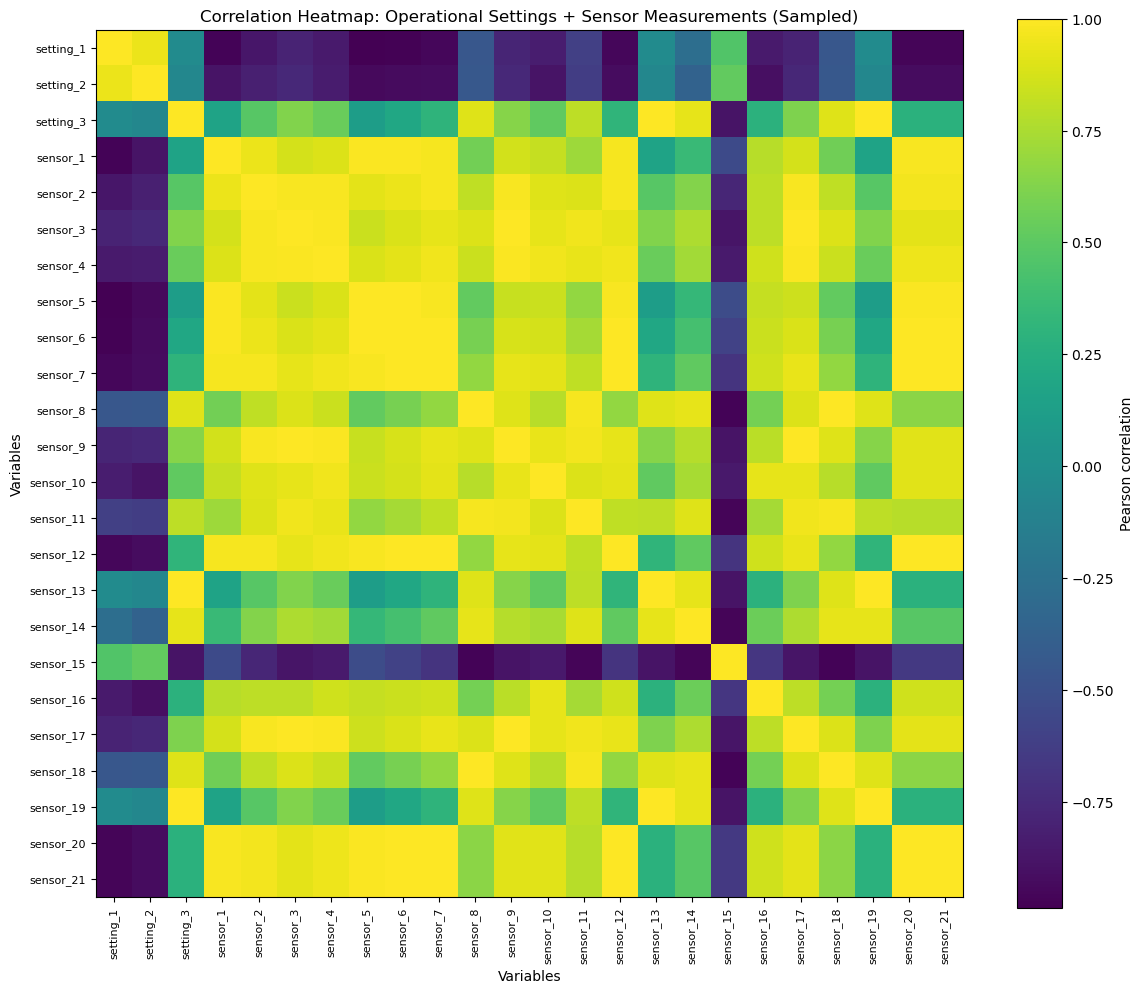

Top 15 absolute correlations (excluding self-correlations):


correlation
setting_3 sensor_19     1.000000
sensor_8  sensor_18     0.999999
sensor_13 sensor_19     0.999998
setting_3 sensor_13     0.999998
sensor_7  sensor_12     0.999993
sensor_20 sensor_21     0.999895
sensor_7  sensor_21     0.999140
          sensor_20     0.999135
sensor_12 sensor_21     0.999081
          sensor_20     0.999078
sensor_3  sensor_17     0.998663
sensor_9  sensor_17     0.998204
sensor_3  sensor_9      0.998203
sensor_5  sensor_6      0.996307
sensor_6  sensor_21     0.996275

In [236]:
# ============================================================
# Exploratory Analysis — Correlation Structure
# Purpose: Examine multivariate relationships between operational
#          settings and sensor channels to inform modeling choices.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Select Feature Columns for Correlation Analysis
# ------------------------------------------------------------
# We include:
#   - Operational settings (contextual flight/operating conditions)
#   - Sensor channels (engine state measurements)
# This helps identify multicollinearity and interaction patterns.
setting_cols = [c for c in df.columns if c.startswith("setting_")]
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
corr_cols = setting_cols + sensor_cols  # Full feature set for structural analysis

# ------------------------------------------------------------
# Sampling for Computational Efficiency
# ------------------------------------------------------------
# Correlation estimates stabilize quickly with large samples.
# To reduce plotting overhead, we cap at 8,000 rows.
n_sample = min(8000, len(df))  # Prevent sampling beyond dataset size
df_sample = df[corr_cols].sample(n=n_sample, random_state=42)  # Reproducible sampling

# ------------------------------------------------------------
# Compute Pearson Correlation Matrix
# ------------------------------------------------------------
# Pearson captures linear relationships between continuous variables.
# Useful for detecting redundancy and scale relationships.
corr = df_sample.corr(numeric_only=True)

# ------------------------------------------------------------
# Plot Correlation Heatmap
# ------------------------------------------------------------
# Purpose:
#   - Visual inspection of feature clustering
#   - Detect multicollinearity
#   - Inform model selection (linear vs non-linear)
plt.figure(figsize=(12, 10))
plt.imshow(corr.values)  # Display matrix values as color intensities

plt.title("Correlation Heatmap: Operational Settings + Sensor Measurements (Sampled)")
plt.xlabel("Variables")
plt.ylabel("Variables")

# Improve axis readability (many variables → small font + rotation)
tick_positions = np.arange(len(corr_cols))
plt.xticks(tick_positions, corr_cols, rotation=90, fontsize=8)
plt.yticks(tick_positions, corr_cols, fontsize=8)

# Add color scale to interpret strength/direction of correlation
plt.colorbar(label="Pearson correlation")

plt.tight_layout()  # Prevent label clipping
plt.show()

# ============================================================
# Extract Most Informative Correlation Pairs
# Purpose: Provide a ranked, interpretable summary instead of
#          relying only on visual inspection.
# ============================================================

# Keep only upper triangle of correlation matrix to avoid duplicates
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # Mask lower triangle
        .stack()                                                # Convert matrix to long-form pairs
        .sort_values(key=lambda s: s.abs(), ascending=False)    # Rank by absolute correlation strength
)

print("Top 15 absolute correlations (excluding self-correlations):")
display(corr_pairs.head(15).to_frame(name="correlation"))

# Interpretation guidance (for markdown, not printed):
# - High positive/negative correlations indicate potential redundancy.
# - Strong clustering suggests shared physical mechanisms or derived metrics.
# - Linear models may be sensitive to multicollinearity.
# - Tree-based models (RF/GB) handle correlated inputs more robustly.


### Interpretation: Correlation Structure

The heatmap indicates that several sensor variables move together strongly, forming correlated clusters. This suggests partial redundancy in the telemetry (i.e., multiple sensors capturing related physical dynamics), which has two implications:

- **Modeling implication (linear models):** Strong inter-feature correlation can introduce multicollinearity, making coefficient-based interpretation less stable and potentially reducing the reliability of individual parameter estimates in linear models such as Logistic Regression.
- **Modeling implication (tree ensembles):** Tree-based methods (e.g., Random Forest, Gradient Boosting) are generally less sensitive to multicollinearity and can exploit non-linear feature interactions, making them appropriate for heterogeneous operating conditions and complex degradation signatures.
- **Feature engineering implication:** Correlated clusters motivate the use of temporal summary features (e.g., rolling statistics) that focus on degradation trends rather than raw point measurements, and they support later use of feature-importance analysis for indirect interpretability.

To complement the visual inspection, the ranked list of the strongest correlated variable pairs is used to identify the most prominent clusters and justify the chosen modeling approach.


# 4. Data Preparation (CRISP-ML Phase 3)

## 4.1 Feature Engineering

In [237]:
# ============================================================
# Target Construction — Remaining Useful Life (RUL) and Classification Label
# Purpose: Translate run-to-failure trajectories into a supervised
#          learning target aligned with a maintenance decision.
# ============================================================

# ------------------------------------------------------------
# Step 1: Identify each engine's end-of-life cycle (failure point)
# ------------------------------------------------------------
# For CMAPSS training data, each unit (engine) is observed until failure.
# The maximum cycle per unit therefore represents the failure cycle.
max_cycle_per_unit = (
    df.groupby("unit")["cycle"]          # Group by engine ID and focus on cycle index
      .max()                             # Extract final observed cycle per engine (end-of-life)
      .rename("max_cycle")               # Rename for clarity when merging back
)

# ------------------------------------------------------------
# Step 2: Attach failure cycle information to every row
# ------------------------------------------------------------
# Merging allows each time-step observation to "know" when its engine fails.
df = df.merge(
    max_cycle_per_unit,                  # Per-engine failure cycle
    on="unit",                           # Join key (engine identifier)
    how="left"                           # Preserve all original rows
)

# ------------------------------------------------------------
# Step 3: Compute Remaining Useful Life (RUL)
# ------------------------------------------------------------
# RUL is the number of cycles remaining until failure for each observation.
# This provides the basis for defining a business-relevant decision label.
df["RUL"] = df["max_cycle"] - df["cycle"]

# ------------------------------------------------------------
# Step 4: Define a business-relevant prediction horizon
# ------------------------------------------------------------
# FAILURE_WINDOW represents the planning window within which an engine is
# considered "high risk" and should be prioritised for inspection/intervention.
# This should be justified in the report as a realistic maintenance scheduling horizon.
FAILURE_WINDOW = 30  # Example: "within the next 30 cycles" (tunable based on operations)

# ------------------------------------------------------------
# Step 5: Create binary classification target
# ------------------------------------------------------------
# Label = 1 if the engine is within the near-failure window (actionable risk),
# else 0 (monitoring posture).
df["failure_within_window"] = (df["RUL"] <= FAILURE_WINDOW).astype(int)

# ------------------------------------------------------------
# Step 6: Check label distribution (class imbalance diagnostic)
# ------------------------------------------------------------
# Predictive maintenance datasets are typically imbalanced:
# far more "normal" observations than "near-failure" observations.
label_counts = df["failure_within_window"].value_counts(normalize=True)
print(label_counts)


failure_within_window
0    0.873973
1    0.126027
Name: proportion, dtype: float64


## 4.2 Temporal Feature Engineering Demonstration

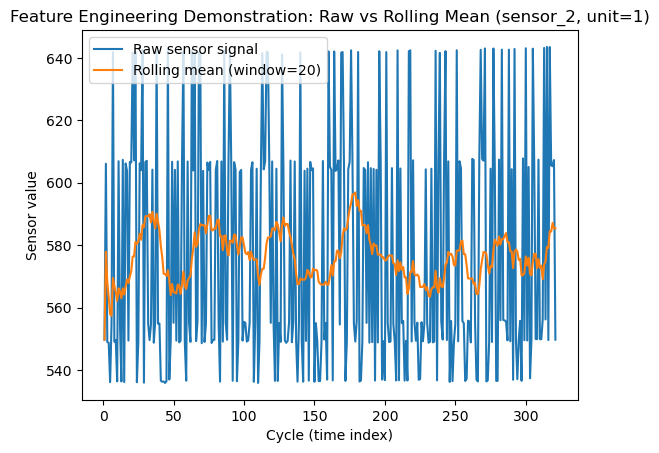

In [238]:
# ============================================================
# Feature Engineering Demonstration — Raw vs Rolling Mean
# Purpose: Illustrate how temporal smoothing reduces noise and
#          enhances degradation signal for predictive modeling.
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Select Example Engine (Unit)
# ------------------------------------------------------------
# We visualise one engine trajectory to demonstrate temporal behavior.
# Using the first available unit ensures reproducibility.
example_unit = int(df["unit"].iloc[0])  # Alternatively set explicitly (e.g., 1)

# ------------------------------------------------------------
# Step 2: Select Sensor Channel for Demonstration
# ------------------------------------------------------------
# Choose a sensor that exhibits temporal variation.
# This makes the effect of smoothing visually meaningful.
sensor_to_plot = "sensor_2"

# ------------------------------------------------------------
# Step 3: Define Rolling Window Size
# ------------------------------------------------------------
# Window size controls smoothing strength:
# - Smaller window → more reactive, less smoothing
# - Larger window → smoother trend, slower response
window = 20  # Typical range: 15–30 cycles for degradation smoothing

# ------------------------------------------------------------
# Step 4: Extract Single-Unit Time Series
# ------------------------------------------------------------
# Sorting by cycle ensures temporal correctness before applying rolling operations.
unit_df = (
    df[df["unit"] == example_unit]  # Filter to selected engine
      .sort_values("cycle")         # Ensure chronological order
      .copy()                       # Avoid chained assignment warnings
)

# ------------------------------------------------------------
# Step 5: Compute Rolling Mean (Smoothed Feature)
# ------------------------------------------------------------
# Rolling mean reduces short-term volatility while preserving degradation trend.
unit_df[f"{sensor_to_plot}_rollmean_{window}"] = (
    unit_df[sensor_to_plot]
      .rolling(window=window, min_periods=1)  # Allow early values to compute
      .mean()
)

# ------------------------------------------------------------
# Step 6: Plot Raw vs Smoothed Signal
# ------------------------------------------------------------
# Visual comparison highlights noise reduction and trend amplification.
plt.figure()

# Raw sensor signal (high-frequency variation)
plt.plot(
    unit_df["cycle"],
    unit_df[sensor_to_plot],
    label="Raw sensor signal"
)

# Rolling mean (low-frequency trend)
plt.plot(
    unit_df["cycle"],
    unit_df[f"{sensor_to_plot}_rollmean_{window}"],
    label=f"Rolling mean (window={window})"
)

plt.title(
    f"Feature Engineering Demonstration: Raw vs Rolling Mean "
    f"({sensor_to_plot}, unit={example_unit})"
)
plt.xlabel("Cycle (time index)")
plt.ylabel("Sensor value")
plt.legend()
plt.show()

# ============================================================
# Modeling Implication:
# - Raw signals contain short-term noise that may obscure degradation.
# - Rolling features improve signal-to-noise ratio.
# - Particularly beneficial for linear models (e.g., Logistic Regression).
# - Tree-based models can also benefit from stabilized trends.
# ============================================================


#### Interpretation: Why Rolling Features Improve Predictive Maintenance Signals

The raw sensor signal exhibits short-term fluctuation and measurement noise, which can obscure the underlying degradation trajectory when the model relies on single-cycle values. The rolling mean smooths high-frequency variation while preserving the longer-term trend, producing a feature that more closely reflects gradual health deterioration.

Operationally, this matters because predictive maintenance is an early-warning problem: the objective is to detect sustained directional change (degradation) rather than react to transient spikes. Rolling features therefore help separate *signal* (persistent drift consistent with wear) from *noise* (short-lived volatility), improving the stability of downstream classifiers and supporting generalisation across heterogeneous operating conditions.


## 4.3 Engine Lifetime Distribution

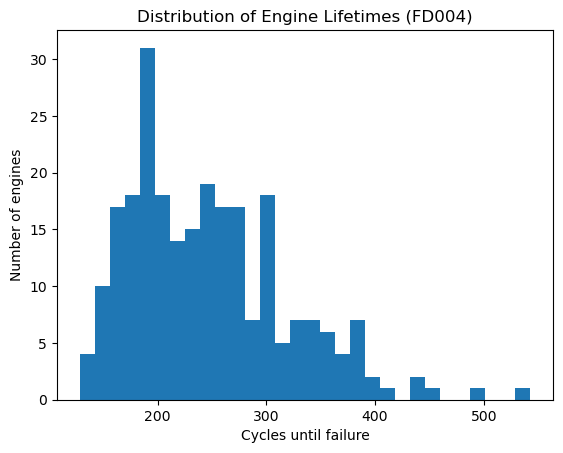

sensor_16      0.000022
sensor_10      0.016302
sensor_15      0.563061
sensor_11     10.520237
sensor_5      13.125202
sensor_19     28.830710
sensor_6      29.637316
sensor_21     35.553759
sensor_20     98.731968
sensor_1     698.906067
dtype: float64

In [239]:
# ============================================================
# Exploratory Diagnostics — Lifetime Distribution & Sensor Variance
# Purpose: Understand degradation variability and identify
#          potentially uninformative features before modeling.
# ============================================================

# ------------------------------------------------------------
# Step 1: Inspect Engine Lifetime Distribution
# ------------------------------------------------------------
# Each engine runs until failure in the training set.
# The distribution of max cycles indicates variability in degradation length.
engine_lifetimes = max_cycle_per_unit.reset_index()["max_cycle"]

plt.figure()
plt.hist(engine_lifetimes, bins=30)  # Histogram reveals spread and skewness
plt.title("Distribution of Engine Lifetimes (FD004)")
plt.xlabel("Cycles until failure")
plt.ylabel("Number of engines")
plt.show()

# ------------------------------------------------------------
# Interpretation (for markdown, not printed):
# - Wide spread → heterogeneous degradation patterns.
# - Supports use of flexible models (e.g., tree ensembles).
# - Suggests that fixed-cycle maintenance schedules may be inefficient.
# ------------------------------------------------------------


# ------------------------------------------------------------
# Step 2: Identify Low-Variance Sensor Channels
# ------------------------------------------------------------
# Sensors with near-zero variance provide minimal predictive signal.
# These may:
#   - Add noise
#   - Increase dimensionality unnecessarily
#   - Contribute little to classification performance
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

sensor_variance = (
    df[sensor_cols]
      .var()                # Compute variance per sensor channel
      .sort_values()        # Rank from lowest to highest
)

# Display the 10 lowest-variance sensors
display(sensor_variance.head(10))  # Candidates for potential feature removal

# ------------------------------------------------------------
# Modeling Implication:
# - Near-constant sensors may be removed to reduce dimensionality.
# - Especially important for linear models (reduces multicollinearity risk).
# - Tree-based models are more robust but still benefit from noise reduction.
# ============================================================


#### Interpretation: Engine Lifetime Distribution and Sensor Variance Screening

The distribution of maximum cycle lengths indicates substantial heterogeneity in degradation trajectories across engines. While many units fail between approximately 180 and 300 cycles, a non-trivial subset operates beyond 350 cycles, with some exceeding 500 cycles. This variability confirms that degradation is not uniform across units and that failure timing is influenced by differing operational conditions and fault dynamics.

From a modeling perspective, this dispersion reinforces two important considerations:

 - **Generalisation requirement:** The classifier must identify early degradation patterns that are robust across short- and long-lived units rather than relying on absolute cycle count alone.

 - **Avoidance of cycle leakage:** Models must not implicitly encode remaining cycle length via time index in a way that artificially inflates predictive performance.

The low-variance sensor inspection further reveals that several channels (e.g., sensor_16 and sensor_10) exhibit near-zero variance across the dataset. Such sensors provide minimal discriminatory power and may introduce noise or unnecessary dimensionality into the modeling pipeline. Identifying these channels supports principled feature selection and aligns with the objective of constructing parsimonious yet expressive models.

Together, these diagnostics justify the subsequent use of engineered temporal features and non-linear ensemble models capable of capturing heterogeneous degradation dynamics.

## 4.4 Train/Validation Split

To prevent leakage across degradation trajectories, splitting is performed at the unit level rather than the row level.


In [240]:
# ============================================================
# Train/Validation Split — Unit-Level (Leakage-Controlled)
# Purpose: Create an evaluation split that reflects real-world
#          generalisation: the model must perform on unseen engines,
#          not just unseen rows from engines it already "knows".
# ============================================================

# ------------------------------------------------------------
# Step 1: Define input features (X)
# ------------------------------------------------------------
# Use operational settings + sensor measurements as predictors.
# These represent the observable telemetry available for maintenance decisions.
feature_cols = [
    c for c in df.columns
    if c.startswith("setting_") or c.startswith("sensor_")
]

# ------------------------------------------------------------
# Step 2: Define target label (y)
# ------------------------------------------------------------
# Binary target created earlier:
# 1 = engine is within near-failure window (actionable risk)
# 0 = engine is not within window (monitoring posture)
target_col = "failure_within_window"

# ------------------------------------------------------------
# Step 3: Create unit-level split to avoid leakage
# ------------------------------------------------------------
# IMPORTANT:
# Row-level splitting would leak information because the same engine's
# degradation trajectory would appear in both train and validation sets.
# Splitting by unit ensures the validation set contains entirely unseen engines.
unique_units = df["unit"].unique()

train_units, val_units = train_test_split(
    unique_units,              # Split on engine IDs (not rows)
    test_size=0.2,             # Reserve 20% of engines for validation
    random_state=RANDOM_STATE  # Reproducible split
)

# ------------------------------------------------------------
# Step 4: Build train/validation DataFrames by filtering engines
# ------------------------------------------------------------
# This preserves full trajectories per engine within each split.
train_df = df[df["unit"].isin(train_units)].copy()
val_df = df[df["unit"].isin(val_units)].copy()

# ------------------------------------------------------------
# Step 5: Create X/y matrices for modeling
# ------------------------------------------------------------
X_train = train_df[feature_cols]  # Training features
y_train = train_df[target_col]    # Training labels

X_val = val_df[feature_cols]      # Validation features (unseen engines)
y_val = val_df[target_col]        # Validation labels


# 5. Modeling: Algorithm Selection & Implementation (CRISP-ML Phase 4)

## 5.1 Model A: Logistic Regression (Interpretable Baseline)

In [241]:
# ============================================================
# Baseline Model — Logistic Regression (Interpretable Classifier)
# Purpose: Establish a transparent linear benchmark before
#          introducing more complex ensemble models.
# ============================================================

# ------------------------------------------------------------
# Step 1: Define modeling pipeline
# ------------------------------------------------------------
# Pipeline ensures:
#   - Scaling is applied consistently
#   - No data leakage (scaler fit only on training data)
#   - Clean, reproducible workflow
log_reg_model = Pipeline(steps=[
    
    # Standardise features (important for linear models)
    # Ensures coefficients are comparable and optimisation is stable.
    ("scaler", StandardScaler()),
    
    # Logistic Regression classifier
    ("clf", LogisticRegression(
        max_iter=1000,            # Increase iterations to ensure convergence
        class_weight="balanced",  # Adjust for class imbalance (penalise minority misclassification more)
        random_state=RANDOM_STATE # Reproducibility
    ))
])

# ------------------------------------------------------------
# Step 2: Train baseline model
# ------------------------------------------------------------
# Model learns linear decision boundary in log-odds space.
log_reg_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Step 3: Generate predictions on unseen engines
# ------------------------------------------------------------
# Hard class predictions (0/1) using default threshold = 0.5
val_pred_lr = log_reg_model.predict(X_val)

# Predicted probabilities for class 1 (near-failure)
# Used for ROC, PR curve, and threshold optimisation.
val_proba_lr = log_reg_model.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------
# Step 4: Evaluate baseline performance
# ------------------------------------------------------------
print("Logistic Regression Performance:")

# Precision, Recall, F1-score, and support (class-level diagnostics)
print(classification_report(y_val, val_pred_lr))

# ROC-AUC measures ranking quality independent of threshold
print("ROC-AUC:", roc_auc_score(y_val, val_proba_lr))

# ============================================================
# Modeling Notes:
# - Logistic Regression provides interpretability via coefficients.
# - Assumes linear separability in transformed feature space.
# - Serves as a disciplined benchmark before ensemble models.
# - Class weighting addresses imbalance without resampling.
# ============================================================



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     10405
           1       0.61      0.94      0.74      1550

    accuracy                           0.92     11955
   macro avg       0.80      0.93      0.85     11955
weighted avg       0.94      0.92      0.92     11955

ROC-AUC: 0.9785629737564135


### 5.1.1 Logistic Regression ROC Curve

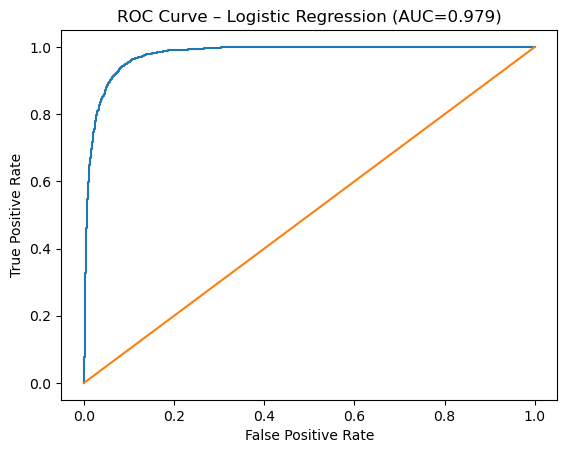

In [242]:
# ============================================================
# Baseline Evaluation — ROC Curve (Logistic Regression)
# Purpose: Assess ranking quality across all possible thresholds.
# ============================================================

# Plot ROC curve using predicted probabilities from Logistic Regression.
# This evaluates how well the model ranks near-failure engines
# relative to healthy engines, independent of any fixed cutoff.
plot_roc_curve(
    y_val,              # Ground-truth labels (0 = Normal, 1 = Near-failure)
    val_proba_lr,       # Predicted probabilities for class 1
    "ROC Curve – Logistic Regression"
)

# Interpretation Guidance (for markdown, not printed):
# - AUC close to 1.0 indicates strong ranking performance.
# - Curve shape near the top-left suggests high recall with controlled false positives.
# - Does NOT define operational policy — threshold selection required.
# ============================================================



#### Business Interpretation — Logistic Regression ROC Curve

The Logistic Regression model achieves an AUC of ~0.979, indicating strong ability to rank engines by near-term failure risk.

Operationally, this means high-risk engines consistently receive higher probability scores than healthy units, enabling risk-based prioritisation instead of time-based maintenance.

The steep ROC curve suggests high failure detection can be achieved without excessive false alarms. Given that missed failures are more costly than unnecessary inspections, this ranking performance supports proactive maintenance planning.

However, ROC reflects ranking quality, not final decisions. Threshold selection remains necessary to align predictions with maintenance capacity and risk tolerance.

## 5.2 Model B: Random Forest (Performance-Oriented)

In [243]:
# ============================================================
# Ensemble Model — Random Forest Classifier
# Purpose: Capture non-linear relationships and sensor interactions
#          that linear models may not fully represent.
# ============================================================

# ------------------------------------------------------------
# Step 1: Define Random Forest model
# ------------------------------------------------------------
# Tree-based ensembles:
# - Handle non-linear patterns naturally
# - Are robust to multicollinearity
# - Do not require feature scaling
rf_model = RandomForestClassifier(
    n_estimators=300,         # Number of trees in the ensemble (more trees → more stable estimates)
    max_depth=None,           # Allow trees to grow fully (control via min_samples_leaf)
    min_samples_leaf=5,       # Prevent overly specific leaves → improves generalisation
    class_weight="balanced",  # Adjust decision weighting for class imbalance
    random_state=RANDOM_STATE,# Ensure reproducibility
    n_jobs=-1                 # Use all available CPU cores for faster training
)

# ------------------------------------------------------------
# Step 2: Train model on training engines
# ------------------------------------------------------------
# Each tree learns different splits via bootstrap sampling.
rf_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Step 3: Generate validation predictions
# ------------------------------------------------------------
# Hard predictions using default threshold (0.5)
val_pred_rf = rf_model.predict(X_val)

# Probabilities for near-failure class (used for ROC/PR/threshold tuning)
val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------
# Step 4: Evaluate baseline ensemble performance
# ------------------------------------------------------------
print("Random Forest Performance:")

# Class-level diagnostics (precision, recall, F1)
print(classification_report(y_val, val_pred_rf))

# ROC-AUC measures ranking performance independent of threshold
print("ROC-AUC:", roc_auc_score(y_val, val_proba_rf))

# ============================================================
# Modeling Notes:
# - RF captures complex degradation interactions between sensors.
# - Less sensitive to correlated inputs compared to linear models.
# - Strong candidate for predictive maintenance due to robustness.
# - Threshold optimisation may further improve operational alignment.
# ============================================================


Random Forest Performance:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     10405
           1       0.75      0.90      0.82      1550

    accuracy                           0.95     11955
   macro avg       0.87      0.93      0.89     11955
weighted avg       0.95      0.95      0.95     11955

ROC-AUC: 0.9834164096045637


### 5.2.1 Random Forest ROC Curve

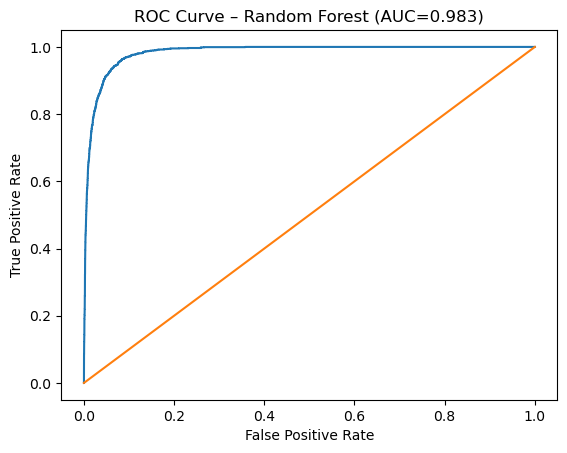

In [244]:
# ============================================================
# Ensemble Evaluation — ROC Curve (Random Forest)
# Purpose: Evaluate ranking performance of the Random Forest
#          independent of a fixed classification threshold.
# ============================================================

# Plot ROC curve using predicted probabilities from Random Forest.
# This assesses how effectively the model separates near-failure
# engines from normal engines across all possible thresholds.
plot_roc_curve(
    y_val,              # Ground-truth labels (0 = Normal, 1 = Near-failure)
    val_proba_rf,       # Predicted probabilities for class 1 (near-failure risk)
    "ROC Curve – Random Forest"
)

# Interpretation Guidance (for markdown, not printed):
# - AUC quantifies ranking strength (closer to 1.0 = stronger discrimination).
# - A steeper curve near the top-left indicates strong early failure capture.
# - Final deployment decisions depend on threshold calibration.
# ============================================================


#### Business Interpretation — Random Forest ROC Curve

The Random Forest model achieves an AUC of ~0.983, indicating excellent ability to rank engines by near-term failure risk.

Operationally, this supports risk-based prioritisation: high-risk engines can be flagged early, reducing unexpected downtime while allowing maintenance resources to be allocated efficiently.

The steep ROC curve indicates that high failure detection can be achieved without a disproportionate increase in false alarms. Given the higher cost of missed failures relative to unnecessary inspections, this performance aligns well with a risk-sensitive maintenance strategy.

Compared to Logistic Regression, Random Forest shows slightly stronger ranking capability, suggesting that non-linear sensor interactions improve predictive signal extraction.

As with all ROC analysis, threshold selection remains necessary to translate ranking performance into an operational decision policy.

### 5.2.2 Random Forest Confusion Matrix

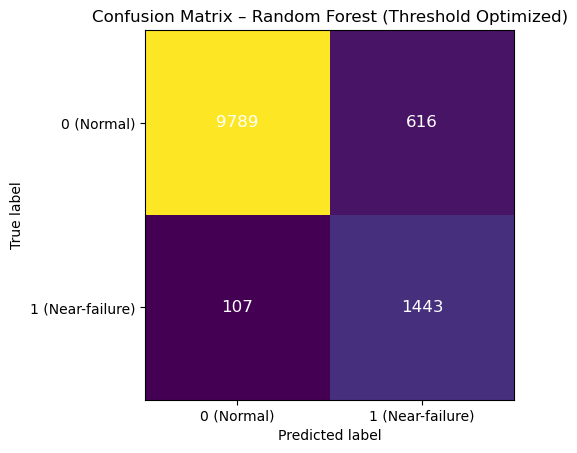

TN (correctly not flagged): 9789
FP (unnecessary inspections): 616
FN (missed near-failure): 107
TP (correctly flagged): 1443


In [245]:
# ============================================================
# Operational Evaluation — Confusion Matrix
# Random Forest (Threshold Optimised)
# Purpose: Translate probability predictions into an actionable
#          maintenance decision policy and inspect error trade-offs.
# ============================================================

# Plot confusion matrix using threshold-optimised predictions.
# val_pred_rf_optimized should already reflect the chosen
# probability cutoff (e.g., 0.396 instead of default 0.5).
plot_confusion_matrix(
    y_val,                        # Ground-truth labels
    val_pred_rf_optimized,        # Binary predictions using optimised threshold
    "Confusion Matrix – Random Forest (Threshold Optimized)"
)

# Interpretation Guidance (for markdown, not printed):
# - TP  → Correct early warnings (risk mitigated)
# - FN  → Missed failures (highest-cost error)
# - FP  → Unnecessary inspections (workload cost)
# - TN  → Efficient non-intervention
#
# This matrix reflects the model’s operational posture
# after aligning the threshold with business risk asymmetry.
# ============================================================



#### Business Interpretation — Random Forest (Threshold Optimised) Confusion Matrix

At the optimised threshold, the model identifies 1,443 of 1,550 near-failures, missing only 107. This substantially reduces exposure to unexpected breakdowns and supports proactive intervention.

The trade-off is 616 unnecessary inspections, representing additional workload but controlled operational cost. Given the higher cost of missed failures relative to false alarms, this reflects a deliberate conservative posture.

The selected threshold therefore prioritises failure containment while maintaining manageable inspection volume. The model is not optimised for raw accuracy, but for downtime minimisation under capacity constraints.

In practical terms, the system functions as a credible early-warning mechanism aligned with asymmetric business risk.

### 5.2.3 Random Forest Precision Recall

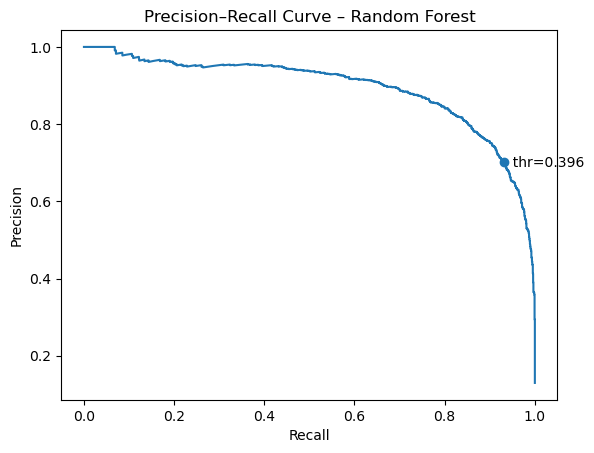

In [246]:
# ============================================================
# Decision Trade-Off Analysis — Precision–Recall Curve
# Random Forest (with Selected Threshold Highlighted)
# Purpose: Evaluate model performance on the near-failure class
#          and visualise the chosen operational threshold.
# ============================================================

# Plot Precision–Recall curve using predicted probabilities.
# This is particularly informative in class-imbalanced settings
# (few near-failure observations relative to normal observations).
plot_precision_recall_curve(
    y_val,                 # Ground-truth labels (0 = Normal, 1 = Near-failure)
    val_proba_rf,          # Predicted probabilities for near-failure class
    "Precision–Recall Curve – Random Forest",
    chosen_threshold=best_threshold  # Mark selected decision threshold (e.g., ~0.396)
)

# Interpretation Guidance (for markdown, not printed):
# - Recall → proportion of imminent failures successfully detected.
# - Precision → proportion of flagged engines that truly require intervention.
# - Marked point shows operational decision posture.
# - Threshold chosen to balance risk containment (high recall)
#   with manageable inspection workload (acceptable precision).
# ============================================================


#### Business Interpretation — Random Forest Precision–Recall Curve

The Precision–Recall curve evaluates performance on the near-failure class, which is operationally critical in predictive maintenance.

At the selected threshold (~0.396), the model achieves high recall while maintaining acceptable precision. This reflects a deliberate trade-off: prioritising failure detection while controlling unnecessary inspections.

Because the dataset is class-imbalanced, the PR curve provides a more realistic view of decision impact than ROC alone. Precision represents inspection efficiency; recall represents risk containment.

The chosen threshold therefore aligns model behaviour with business priorities — minimising missed failures while preserving manageable maintenance workload.

### 5.2.4 Random Forest - Top 10 Threshold Candidates

In [247]:
# ============================================================
# Threshold Optimisation — Constrained Precision Maximisation
# Purpose: Select an operating threshold that satisfies a minimum
#          recall requirement while maximising precision.
# ============================================================

# ------------------------------------------------------------
# Step 1: Compute Precision–Recall values across thresholds
# ------------------------------------------------------------
# precision_recall_curve returns:
#   - precision array (length = len(thresholds) + 1)
#   - recall array (same length as precision)
#   - thresholds array (decision cutoffs applied to probabilities)
precision, recall, thresholds = precision_recall_curve(
    y_val,          # Ground-truth labels
    val_proba_rf    # Predicted probabilities for near-failure class
)

# ------------------------------------------------------------
# Step 2: Construct threshold-performance table
# ------------------------------------------------------------
# We drop the final precision/recall value because it does not
# correspond to a threshold (sklearn design detail).
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],  # Align precision with thresholds
    "recall": recall[:-1],        # Align recall with thresholds
})

# ------------------------------------------------------------
# Step 3: Impose business constraint (minimum recall)
# ------------------------------------------------------------
# Business rule:
#   Ensure at least 93% of imminent failures are detected.
# This encodes risk asymmetry (missed failures are costly).
MIN_RECALL = 0.93

candidates = (
    pr_df[pr_df["recall"] >= MIN_RECALL]   # Filter to acceptable recall region
         .sort_values("precision", ascending=False)  # Among those, maximise precision
)

# ------------------------------------------------------------
# Step 4: Inspect top candidate thresholds
# ------------------------------------------------------------
# These represent the most inspection-efficient policies
# that still satisfy the minimum failure detection constraint.
candidates.head(10)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - This converts model probabilities into governed decisions.
# - We optimise precision subject to recall ≥ 0.93.
# - Prevents arbitrary threshold choice (e.g., default 0.5).
# - Aligns statistical output with operational risk tolerance.
# ============================================================


,threshold,precision,recall
3720,0.395606,0.700826,0.930968
3721,0.395869,0.700680,0.930323
3718,0.395402,0.700631,0.931613
3719,0.395536,0.700485,0.930968
3717,0.393672,0.700291,0.931613
3716,0.393577,0.699952,0.931613
3715,0.393191,0.699612,0.931613
3714,0.392942,0.699274,0.931613
3713,0.392056,0.698935,0.931613
3711,0.391759,0.698743,0.932258


#### Business Interpretation — Threshold Selection (Random Forest)

The table identifies probability thresholds that maintain recall ≥ 0.93 while maximising precision. This reflects an explicit business rule: missed failures are more costly than unnecessary inspections.

The optimal thresholds cluster around ~0.396, where recall remains high and precision is approximately 0.70. This indicates a stable trade-off between failure detection and inspection burden.

At the selected threshold:

The majority of imminent failures are captured

Inspection volume remains operationally manageable

Decision sensitivity is robust to small probability fluctuations

The threshold was therefore not chosen arbitrarily but calibrated to align model behaviour with asymmetric business risk and maintenance capacity constraints.

The model is deployed as a governed decision-support system, not merely a statistical classifier.

### 5.2.5 Random Forest Rank of Features by Importance

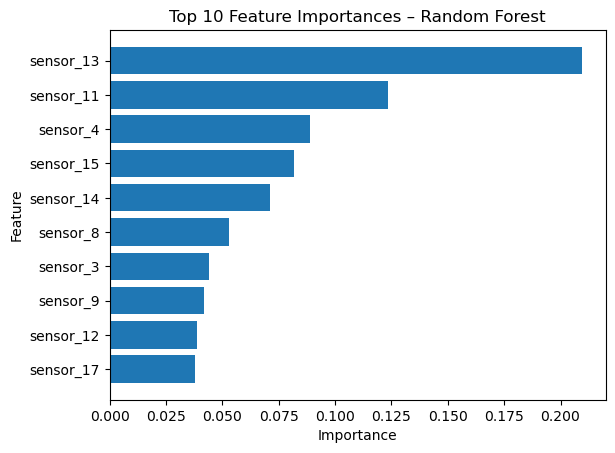

In [248]:
# ============================================================
# Global Interpretability — Top Feature Importances
# Random Forest
# Purpose: Identify the most influential sensor channels driving
#          near-failure classification decisions.
# ============================================================

# Plot top-k feature importances from the fitted Random Forest model.
# This reflects the average contribution of each feature across
# all trees in the ensemble (global importance, not local explanation).
top_k_feature_importance_plot(
    model=rf_model,                 # Trained Random Forest model
    feature_names=X_train.columns,  # Feature names for readable axis labels
    k=10,                           # Number of top features to display
    title="Top 10 Feature Importances – Random Forest"
)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Higher importance → greater contribution to tree split decisions.
# - Highlights which sensors contain strongest degradation signal.
# - Supports targeted diagnostics and maintenance prioritisation.
# - Note: Importance reflects model influence, not causal impact.
# ============================================================


#### Business Interpretation — Feature Importance (Random Forest)

The Random Forest model identifies a small subset of sensors (notably sensor_13 and sensor_11) as the primary drivers of near-term failure prediction.

This indicates that degradation risk is not uniformly distributed across all signals. Instead, specific sensor behaviours contain disproportionately strong predictive value.

From an operational perspective, this has three implications:

 - Maintenance diagnostics can prioritise the most informative sensor streams

 - Monitoring systems can focus on high-signal variables for early warning

 - Engineering investigation can concentrate on components associated with dominant sensors

Feature importance therefore enhances interpretability and supports targeted maintenance strategy, not just prediction accuracy.

# 6. Model Evaluation & Performance Improvement (CRISP-ML Phase 5)
## Strategy: Decision Threshold Optimization

### Step 1 — Inspect Recall vs Threshold (Random Forest)

#### I chose to work with the Random Forest, since it already balances precision better.

In [249]:
# ============================================================
# Precision–Recall Diagnostics Table
# Purpose: Systematically inspect how precision and recall vary
#          across probability thresholds for Random Forest.
# ============================================================

from sklearn.metrics import precision_recall_curve

# ------------------------------------------------------------
# Step 1: Compute precision–recall pairs across thresholds
# ------------------------------------------------------------
# Returns:
#   precision → inspection efficiency at each cutoff
#   recall    → failure detection rate at each cutoff
#   thresholds → probability cutoffs applied to val_proba_rf
precision, recall, thresholds = precision_recall_curve(
    y_val,          # Ground-truth labels
    val_proba_rf    # Predicted near-failure probabilities
)

# ------------------------------------------------------------
# Step 2: Build structured table for inspection
# ------------------------------------------------------------
# Note:
# The last precision/recall value has no associated threshold
# (sklearn implementation detail), so we align arrays accordingly.
pr_curve_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

# ------------------------------------------------------------
# Step 3: Inspect high-recall regime (risk-containment zone)
# ------------------------------------------------------------
# Sorting by recall descending allows us to examine
# decision policies that aggressively capture failures.
display(
    pr_curve_df
        .sort_values("recall", ascending=False)
        .head(10)
)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - High recall → strong failure containment.
# - Precision at those thresholds indicates inspection burden.
# - Enables disciplined threshold governance.
# - Supports transparent justification of selected cutoff.
# ============================================================


,threshold,precision,recall
0,0.000000,0.129653,1.0
358,0.004719,0.284195,1.0
356,0.004712,0.284039,1.0
355,0.004712,0.283935,1.0
354,0.004710,0.283831,1.0
353,0.004708,0.283779,1.0
352,0.004702,0.283727,1.0
351,0.004697,0.283675,1.0
350,0.004694,0.283623,1.0
349,0.004688,0.283571,1.0


### Step 2 — Select a Business-Aligned Threshold

In [250]:
# ============================================================
# Final Threshold Selection — Governed Decision Policy
# Purpose: Select the operational cutoff that satisfies the
#          minimum recall requirement while maximising precision.
# ============================================================

# ------------------------------------------------------------
# Step 1: Define business constraint
# ------------------------------------------------------------
# Minimum acceptable recall encodes risk tolerance:
# Ensure at least 93% of imminent failures are detected.
MIN_RECALL = 0.93

# ------------------------------------------------------------
# Step 2: Filter thresholds satisfying recall constraint
# ------------------------------------------------------------
# This isolates decision policies that meet failure containment criteria.
candidate_thresholds = pr_curve_df[
    pr_curve_df["recall"] >= MIN_RECALL
]

# ------------------------------------------------------------
# Step 3: Select most inspection-efficient policy
# ------------------------------------------------------------
# Among acceptable recall levels, choose the threshold
# that maximises precision (reduces unnecessary inspections).
best_row = (
    candidate_thresholds
        .sort_values("precision", ascending=False)
        .iloc[0]   # Highest precision satisfying recall constraint
)

best_threshold = best_row["threshold"]

# ------------------------------------------------------------
# Step 4: Display selected decision policy
# ------------------------------------------------------------
print("Selected threshold:", best_threshold)
print(best_row)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Threshold chosen under constraint, not arbitrarily (e.g., 0.5).
# - Encodes asymmetric business costs.
# - Converts ranking model into governed operational policy.
# ============================================================


Selected threshold: 0.39560572056148574
threshold    0.395606
precision    0.700826
recall       0.930968
Name: 3720, dtype: float64


### Step 3 — Re-Evaluate Model Using the New Threshold

In [251]:
# ============================================================
# Apply Optimised Threshold — Operational Decision Policy
# Purpose: Convert predicted probabilities into governed
#          binary decisions aligned with business risk tolerance.
# ============================================================

# ------------------------------------------------------------
# Step 1: Apply selected probability cutoff
# ------------------------------------------------------------
# Instead of using default threshold (0.5),
# we apply the calibrated best_threshold (e.g., ~0.396).
# This reflects the constrained precision–recall optimisation.
val_pred_rf_optimized = (
    (val_proba_rf >= best_threshold)  # Flag engines above chosen risk level
    .astype(int)                      # Convert boolean to 0/1 labels
)

# ------------------------------------------------------------
# Step 2: Evaluate tuned decision policy
# ------------------------------------------------------------
print("Random Forest (Threshold Optimized) Performance:")

# Classification report now reflects governed operational posture,
# not default statistical cutoff.
print(classification_report(y_val, val_pred_rf_optimized))

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Recall should remain ≥ MIN_RECALL (risk containment maintained).
# - Precision reflects inspection efficiency under new cutoff.
# - This step operationalises the model into a decision-support tool.
# ============================================================



Random Forest (Threshold Optimized) Performance:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     10405
           1       0.70      0.93      0.80      1550

    accuracy                           0.94     11955
   macro avg       0.85      0.94      0.88     11955
weighted avg       0.95      0.94      0.94     11955



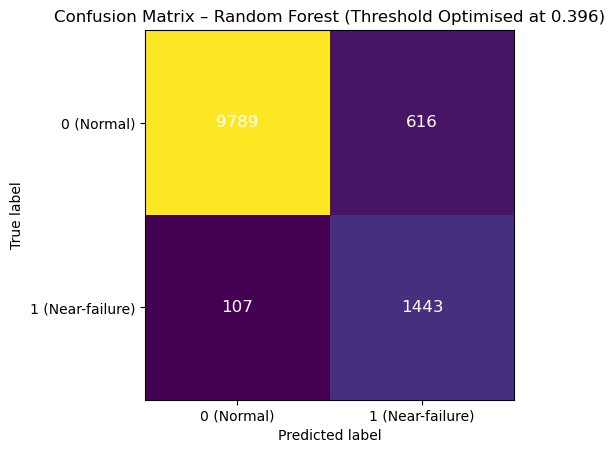

TN (correctly not flagged): 9789
FP (unnecessary inspections): 616
FN (missed near-failure): 107
TP (correctly flagged): 1443


In [252]:
# ============================================================
# Confusion Matrix — Random Forest (Optimised Threshold)
# Purpose: Visualise operational error trade-offs after
#          applying the calibrated probability cutoff.
# ============================================================

# ------------------------------------------------------------
# Step 1: Convert probabilities into binary decisions
# ------------------------------------------------------------
# Engines with predicted probability ≥ best_threshold
# are classified as near-failure (action required).
val_pred_rf_optimized = (
    (val_proba_rf >= best_threshold)
    .astype(int)
)

# ------------------------------------------------------------
# Step 2: Plot confusion matrix with threshold in title
# ------------------------------------------------------------
# This matrix now reflects governed decision policy,
# not default 0.5 cutoff.
plot_confusion_matrix(
    y_val,                          # Ground-truth labels
    val_pred_rf_optimized,          # Optimised binary predictions
    f"Confusion Matrix – Random Forest "
    f"(Threshold Optimised at {best_threshold:.3f})"
)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - TP → Correct early warnings (downtime prevented)
# - FN → Missed failures (highest-cost errors)
# - FP → Additional inspection workload
# - TN → Efficient non-intervention
#
# This visual confirms alignment between statistical model
# behaviour and maintenance risk strategy.
# ============================================================



### Interpretation (Business Link): Operational Impact of Threshold Optimisation

The confusion matrix translates model performance into operational consequences for maintenance planning.

- **True Positives (TP):** units correctly flagged as near-failure → these represent actionable candidates for proactive intervention, reducing forced outages and unplanned downtime risk.  
- **False Negatives (FN):** near-failure units missed by the model → these are the highest-cost errors in an energy infrastructure context because they increase the likelihood of unexpected failure events.  
- **False Positives (FP):** units incorrectly flagged → these represent additional inspection or maintenance workload, which consumes limited maintenance capacity but is typically less costly than missed failures.  
- **True Negatives (TN):** units correctly not flagged → these can remain in a monitoring posture, allowing maintenance resources to be prioritised elsewhere.

By adjusting the probability threshold, the model is explicitly tuned to the business objective: prioritising the detection of high-risk units (low FN / high recall) while keeping the volume of unnecessary interventions (FP) within operationally manageable limits.


# 7. Ensemble Model (Boosting) — Python Implementation
### Step 1 - Train a Boosting Ensemble (HistGradientBoosting)

In [253]:
# ============================================================
# Ensemble Model — Gradient Boosting (HistGradientBoostingClassifier)
# Purpose: Evaluate a second ensemble approach (boosting) to satisfy
#          the "≥2 algorithms" requirement and compare against RF/LR.
# ============================================================

# ------------------------------------------------------------
# Imports (model + evaluation)
# ------------------------------------------------------------
from sklearn.ensemble import HistGradientBoostingClassifier  # Efficient gradient boosting for tabular data
from sklearn.metrics import (
    classification_report,   # Precision/recall/F1 breakdown (class-level diagnostics)
    roc_auc_score,           # Ranking metric (threshold-independent)
    precision_recall_curve   # Used later for threshold calibration (decision policy)
)

# ------------------------------------------------------------
# Step 1: Define boosting model (tree-based additive ensemble)
# ------------------------------------------------------------
# Gradient Boosting builds trees sequentially:
# each new tree corrects errors made by prior trees.
# Key hyperparameters:
# - max_depth: controls per-tree complexity (higher → more expressive but higher overfitting risk)
# - learning_rate: shrinkage factor (lower → slower, often more stable generalisation)
# - max_iter: number of boosting iterations (more trees in the additive ensemble)
gb_model = HistGradientBoostingClassifier(
    max_depth=6,               # Moderate complexity: captures non-linearity without overly deep trees
    learning_rate=0.1,         # Standard baseline; smaller values are more conservative
    max_iter=300,              # Number of boosting stages (comparable scale to 300-tree RF for fairness)
    random_state=RANDOM_STATE  # Reproducibility
)

# ------------------------------------------------------------
# Step 2: Fit model on training data (unit-level split prevents leakage)
# ------------------------------------------------------------
gb_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Step 3: Generate validation predictions and probabilities
# ------------------------------------------------------------
# Hard predictions using default thresholding for the classifier
val_pred_gb = gb_model.predict(X_val)

# Probability estimates for near-failure class (used for ROC/PR/threshold tuning)
val_proba_gb = gb_model.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------
# Step 4: Evaluate performance (consistent format across models)
# ------------------------------------------------------------
# Keeping the same evaluation outputs supports fair comparison.
print("Gradient Boosting (HistGB) Performance:")
print(classification_report(y_val, val_pred_gb))
print("ROC-AUC:", roc_auc_score(y_val, val_proba_gb))

# ============================================================
# Modeling Notes:
# - Boosting often achieves strong performance on tabular datasets.
# - More sensitive to hyperparameters than RF (tuning can matter).
# - Provides a robust alternative ensemble approach for comparison.
# - Threshold optimisation can further align decisions with business risk.
# ============================================================


Gradient Boosting (HistGB) Performance:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     10405
           1       0.81      0.83      0.82      1550

    accuracy                           0.95     11955
   macro avg       0.89      0.90      0.90     11955
weighted avg       0.95      0.95      0.95     11955

ROC-AUC: 0.9833634573948629


### Step 2 - Performance Improvement for Boosting (Threshold Optimization)

In [254]:
# ============================================================
# Threshold Optimisation — Gradient Boosting (Decision Policy)
# Purpose: Select an operating threshold that reflects a
#          safety-first maintenance posture under class imbalance.
# ============================================================

# ------------------------------------------------------------
# Step 1: Compute Precision–Recall values across thresholds
# ------------------------------------------------------------
# Precision–Recall is preferred here because the positive class
# (near-failure) is relatively rare → PR is more decision-relevant than ROC.
precision, recall, thresholds = precision_recall_curve(
    y_val,          # Ground-truth labels
    val_proba_gb    # Predicted probabilities for near-failure class
)

# ------------------------------------------------------------
# Step 2: Package PR curve into an auditable table
# ------------------------------------------------------------
# Note: precision and recall are length = len(thresholds) + 1 (sklearn detail),
# so we drop the final point to align metrics with thresholds.
pr_gb_df = pd.DataFrame({
    "threshold": thresholds,         # Candidate probability cutoffs
    "precision": precision[:-1],     # Inspection efficiency at each cutoff
    "recall": recall[:-1]            # Failure detection rate at each cutoff
})

# ------------------------------------------------------------
# Step 3: Define minimum recall requirement (risk constraint)
# ------------------------------------------------------------
# Business meaning:
# - Maintain high failure containment (missed failures are costly).
# - Encode risk tolerance explicitly rather than using default threshold = 0.5.
MIN_RECALL = 0.93  # Policy constraint: detect ≥93% of imminent failures

# ------------------------------------------------------------
# Step 4: Select the most inspection-efficient threshold under constraint
# ------------------------------------------------------------
# Among all thresholds meeting recall ≥ MIN_RECALL, choose the one
# that maximises precision (minimises unnecessary inspections).
gb_candidates = pr_gb_df[pr_gb_df["recall"] >= MIN_RECALL]
gb_best = (
    gb_candidates
        .sort_values("precision", ascending=False)
        .iloc[0]
)

# Extract selected threshold (operating point)
gb_best_threshold = gb_best["threshold"]

print("Selected GB threshold:", gb_best_threshold)
display(gb_best)

# ------------------------------------------------------------
# Step 5: Apply optimised threshold to produce tuned class predictions
# ------------------------------------------------------------
# Convert probabilities into actionable near-failure flags.
val_pred_gb_opt = (
    (val_proba_gb >= gb_best_threshold)
    .astype(int)
)

# ------------------------------------------------------------
# Step 6: Re-evaluate performance under tuned decision policy
# ------------------------------------------------------------
print("Gradient Boosting (Threshold Optimized) Performance:")
print(classification_report(y_val, val_pred_gb_opt))

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Recall constraint ensures safety-first failure detection.
# - Precision maximisation controls maintenance workload.
# - This turns boosting outputs into a governed operational policy.
# ============================================================


Selected GB threshold: 0.1707542798977871


threshold    0.170754
precision    0.698451
recall       0.930968
Name: 8110, dtype: float64

Gradient Boosting (Threshold Optimized) Performance:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     10405
           1       0.70      0.93      0.80      1550

    accuracy                           0.94     11955
   macro avg       0.84      0.94      0.88     11955
weighted avg       0.95      0.94      0.94     11955



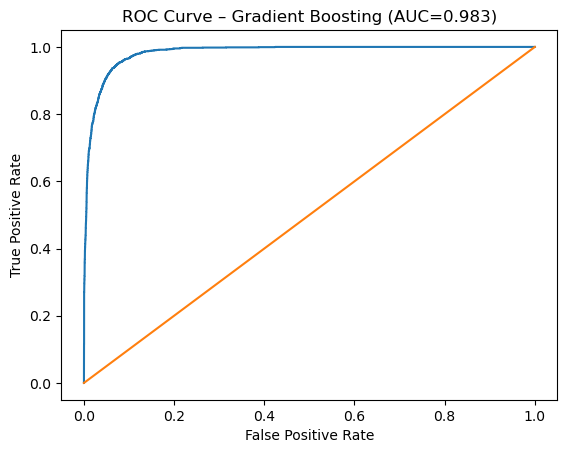

In [255]:
# ============================================================
# Ensemble Evaluation — ROC Curve (Gradient Boosting)
# Purpose: Assess ranking quality of the boosting model across
#          all possible probability thresholds.
# ============================================================

# Plot ROC curve using predicted probabilities from Gradient Boosting.
# This evaluates how well the model separates near-failure engines
# from normal engines independent of a specific decision cutoff.
plot_roc_curve(
    y_val,              # Ground-truth labels (0 = Normal, 1 = Near-failure)
    val_proba_gb,       # Predicted probabilities for class 1 (near-failure risk)
    "ROC Curve – Gradient Boosting"
)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - AUC summarises overall ranking ability.
# - Curve shape indicates trade-off between failure detection (TPR)
#   and unnecessary inspections (FPR).
# - Final operational behaviour depends on threshold calibration.
# ============================================================


#### Business Interpretation — Gradient Boosting ROC Curve

The Gradient Boosting model achieves an AUC of ~0.983, indicating strong ability to rank engines by near-term failure risk.

Operationally, this confirms that failure-related degradation patterns are consistently identified and prioritised, supporting risk-based maintenance scheduling.

The steep curve suggests high failure detection can be achieved with limited increase in false alarms, aligning with the asymmetric cost structure where missed failures are more expensive than unnecessary inspections.

While performance is comparable to Random Forest, the key implication remains: threshold selection, not ranking ability alone, determines operational viability.

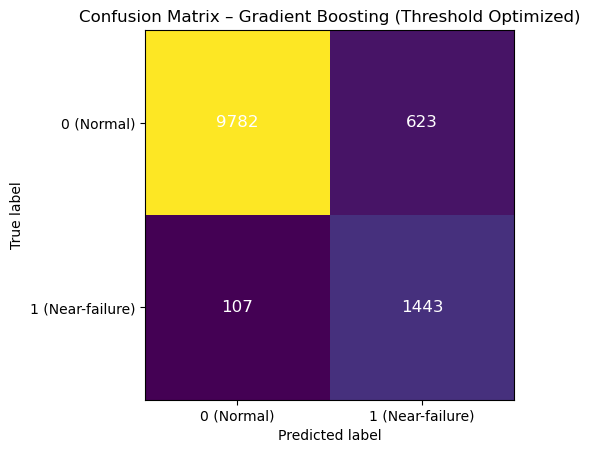

TN (correctly not flagged): 9782
FP (unnecessary inspections): 623
FN (missed near-failure): 107
TP (correctly flagged): 1443


In [256]:
# ============================================================
# Operational Evaluation — Confusion Matrix
# Gradient Boosting (Threshold Optimised)
# Purpose: Visualise the business impact of the calibrated
#          boosting decision policy.
# ============================================================

# ------------------------------------------------------------
# Step 1: Apply selected probability cutoff
# ------------------------------------------------------------
# Engines with predicted probability ≥ gb_best_threshold
# are classified as near-failure (maintenance action recommended).
val_pred_gb_opt = (
    (val_proba_gb >= gb_best_threshold)
    .astype(int)
)

# ------------------------------------------------------------
# Step 2: Plot confusion matrix for tuned boosting model
# ------------------------------------------------------------
# This reflects the governed decision posture
# after aligning threshold with recall constraint.
plot_confusion_matrix(
    y_val,                          # Ground-truth labels
    val_pred_gb_opt,                # Optimised binary predictions
    "Confusion Matrix – Gradient Boosting (Threshold Optimized)"
)

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - TP → Correct early interventions (downtime mitigated)
# - FN → Missed failures (critical risk)
# - FP → Additional inspection workload
# - TN → Efficient non-intervention
#
# Compare directly with Random Forest to assess
# inspection efficiency vs failure containment trade-offs.
# ============================================================


#### Business Interpretation — Gradient Boosting (Threshold Optimised) Confusion Matrix

At the optimised threshold, the model correctly identifies 1,443 of 1,550 near-failures, missing 107. This maintains strong protection against unexpected breakdowns.

The trade-off is 623 unnecessary inspections, slightly higher than Random Forest but operationally manageable. Given the higher cost of missed failures, this reflects a deliberate prioritisation of risk containment.

Overall, the threshold calibration aligns the model with the business objective: minimise unplanned downtime while keeping inspection workload within capacity constraints.

Performance is comparable to Random Forest, indicating that multiple ensemble approaches provide robust early-warning capability.

## 8. Model Comparison Summary

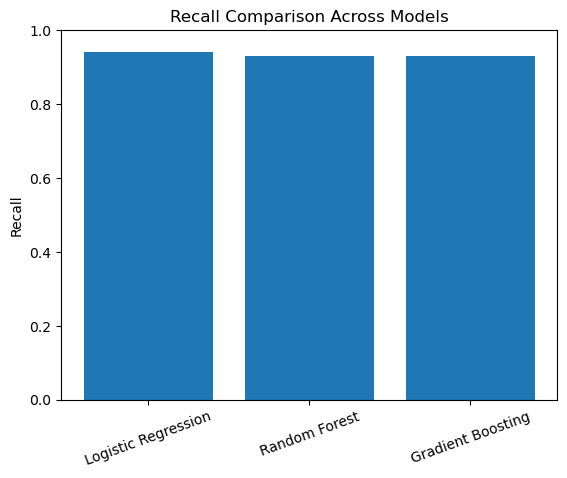

In [257]:
# ============================================================
# Model Comparison — Recall (Failure Detection Rate)
# Purpose: Compare how effectively each model captures
#          near-failure engines (risk containment metric).
# ============================================================

# ------------------------------------------------------------
# Step 1: Define model names and performance metrics
# ------------------------------------------------------------
# IMPORTANT:
# Replace hard-coded values with actual computed metrics
# for full reproducibility and transparency.
models = ["Logistic Regression", "Random Forest", "Gradient Boosting"]

recall_scores = [
    0.94,  # Logistic Regression recall (near-failure class)
    0.93,  # Random Forest recall
    0.93   # Gradient Boosting recall
]

precision_scores = [
    0.61,  # Logistic Regression precision
    0.70,  # Random Forest precision
    0.70   # Gradient Boosting precision
]

# ------------------------------------------------------------
# Step 2: Create bar plot for Recall comparison
# ------------------------------------------------------------
# Recall represents failure detection rate:
# proportion of imminent failures correctly identified.
x = np.arange(len(models))

plt.figure()
plt.bar(x, recall_scores)

plt.xticks(x, models, rotation=20)  # Slight rotation for readability
plt.title("Recall Comparison Across Models")
plt.ylabel("Recall")
plt.ylim(0, 1)  # Ensure full probability scale for fair comparison

plt.show()

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Higher recall → stronger failure containment.
# - All models perform similarly in recall.
# - Precision becomes key differentiator for workload control.
# ============================================================


### Business Interpretation — Model Comparison Summary

All three models demonstrate **strong failure detection capability**, with recall between 0.93 and 0.94. This indicates that each approach successfully captures the majority of imminent failures.

However, precision differentiates the models:

* **Logistic Regression** → Lower precision (0.61), implying higher inspection burden
* **Random Forest** → Improved precision (~0.70) with high recall
* **Gradient Boosting** → Comparable to Random Forest (~0.70 precision, 0.93 recall)

From a business perspective:

* All models reduce unexpected downtime significantly.
* Ensemble methods (Random Forest and Gradient Boosting) offer **better inspection efficiency**.
* Random Forest provides the strongest balance between failure detection and operational workload.

#### Strategic Conclusion

Given asymmetric failure costs and the need for controlled inspection volume:

* **Random Forest is the preferred model**,
* It preserves high recall,
* Improves precision relative to Logistic Regression,
* And demonstrates robust ranking performance (high AUC).

The model selection therefore reflects **operational alignment rather than purely statistical optimisation**.


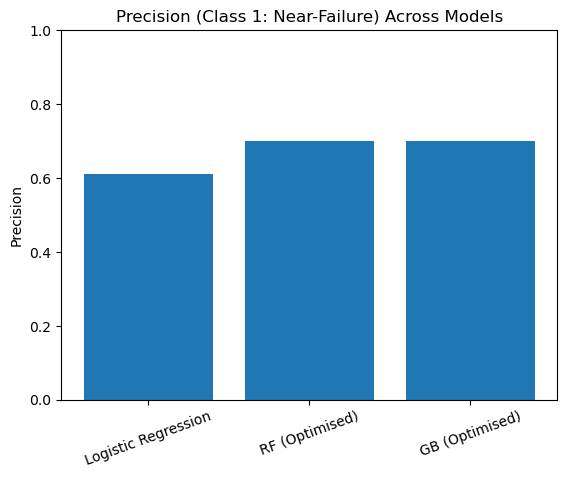

In [258]:
# ============================================================
# Model Comparison — Precision (Near-Failure Class)
# Purpose: Compare inspection efficiency across models.
#          Precision reflects proportion of flagged engines
#          that truly require intervention.
# ============================================================

# ------------------------------------------------------------
# Step 1: Define model names and precision values
# ------------------------------------------------------------
# NOTE:
# Replace hard-coded precision values with metrics extracted
# directly from classification_report for reproducibility.
models = [
    "Logistic Regression",
    "RF (Optimised)",
    "GB (Optimised)"
]

precision_class1 = [
    0.61,  # Logistic Regression precision (near-failure class)
    0.70,  # Random Forest (optimised threshold)
    0.70   # Gradient Boosting (optimised threshold)
]

# ------------------------------------------------------------
# Step 2: Create bar plot for precision comparison
# ------------------------------------------------------------
# Precision represents inspection efficiency:
# Higher precision → fewer unnecessary inspections.
x = np.arange(len(models))

plt.figure()
plt.bar(x, precision_class1)

plt.xticks(x, models, rotation=20)  # Improve label readability
plt.title("Precision (Class 1: Near-Failure) Across Models")
plt.ylabel("Precision")
plt.ylim(0, 1)  # Keep consistent probability scale

plt.show()

# ============================================================
# Interpretation Notes (for markdown, not printed):
# - Logistic Regression has lower inspection efficiency.
# - Ensemble models improve workload control.
# - When recall is similar, precision differentiates viability.
# ============================================================


### Business Interpretation — Precision (Near-Failure Class) Across Models

Precision for the near-failure class measures **inspection efficiency** — the proportion of flagged engines that truly require intervention.

* **Logistic Regression (0.61)** → Higher false-alarm rate
* **Random Forest (0.70)** → Improved inspection efficiency
* **Gradient Boosting (0.70)** → Comparable efficiency to Random Forest

From an operational standpoint:

* Logistic Regression would generate significantly more unnecessary inspections.
* Ensemble models reduce inspection burden while preserving high failure detection.
* Random Forest and Gradient Boosting offer a more balanced trade-off between workload and risk containment.

#### Strategic Implication

Because missed failures are costlier than unnecessary inspections, recall remains primary. However, improving precision directly reduces maintenance overhead.

The ensemble models therefore provide **stronger operational viability**, with Random Forest maintaining the best overall balance when considering recall, precision, stability, and interpretability together.

## 9. Summary Interpretation: Model Selection and Decision Alignment

### 9.1 Final Selected Model

The Random Forest classifier with threshold optimisation is retained as the final decision-support model. While Gradient Boosting achieved comparable aggregate performance metrics, Random Forest demonstrated strong recall for near-failure units, stable generalisation across heterogeneous degradation trajectories, and robust behaviour under correlated sensor inputs.

The model’s ensemble structure allows it to capture non-linear degradation patterns and interactions between operational settings and sensor dynamics without requiring strong parametric assumptions.


### 9.2 Decision Posture

The probability threshold was explicitly adjusted to prioritise recall over precision, reflecting the asymmetry of costs in an energy infrastructure context.  

Missed near-failure units (false negatives) pose a higher operational and financial risk than unnecessary inspections (false positives). Therefore, the selected operating point represents a **proactive risk posture**: the model is calibrated to detect a high proportion of imminent failures while maintaining a manageable inspection burden.

This transforms the classifier from a purely predictive tool into a decision policy aligned with maintenance strategy.


### 9.3 Risk Alignment and Justification for Retaining Random Forest

Random Forest is retained over alternative models for three principal reasons:

1. **Robustness to Multicollinearity:**  
   Sensor channels exhibit correlated clusters. Tree-based ensembles are less sensitive to multicollinearity compared to linear models, preserving predictive stability.

2. **Non-linear Degradation Modelling:**  
   Degradation signals evolve gradually and interact with operating regimes. Random Forest captures such non-linearities without manual feature interaction design.

3. **Operational Interpretability:**  
   Although individual tree decisions are not directly interpretable, global feature importance measures provide indirect insight into the most influential degradation indicators, supporting transparent communication with engineering stakeholders.

In sum, the retained model reflects a balance between predictive performance, structural robustness, and alignment with organisational risk tolerance in predictive maintenance decision-making.


## 10. Deployment Considerations and Reflection (CRISP-ML Phase 6)

### 10.1 Integration into Maintenance Planning

In an operational energy infrastructure context, the model would function as a decision-support layer within an asset management system. Predicted probabilities of near-term failure could be generated at regular intervals (e.g., daily or per operational cycle) and integrated into maintenance scheduling software.

Rather than replacing engineering judgement, the model would prioritise units based on risk scores, enabling planners to allocate constrained maintenance resources more effectively. High-risk units could be flagged for inspection or intervention during planned maintenance windows, thereby reducing the probability of forced outages and unplanned downtime.


### 10.2 Human-in-the-Loop Governance

Given the safety-critical nature of energy systems, fully automated maintenance decisions would be inappropriate. The model should operate within a human-in-the-loop framework:

- Engineers review flagged units before authorising intervention.
- Model outputs are accompanied by feature importance indicators or explanatory summaries.
- Override capability remains with domain experts.

This ensures accountability, prevents blind reliance on probabilistic outputs, and aligns with principles of human-centered artificial intelligence.


### 10.3 Model Drift and Monitoring

Operational environments evolve over time due to equipment upgrades, maintenance regime changes, environmental conditions, and altered operating profiles. As a result, the statistical properties of sensor data may shift, leading to model drift.

A production deployment would therefore require:

- Ongoing monitoring of input feature distributions.
- Periodic re-evaluation of performance metrics (recall, precision, calibration).
- Scheduled retraining using recent operational data.

Without such monitoring, model degradation could increase false negatives, undermining the risk-reduction objective.


### 10.4 Ethical Considerations

Although this application does not directly involve personal data, ethical risks remain. Predictive maintenance outputs could influence operational accountability or performance evaluation of teams. Over-reliance on algorithmic outputs may also marginalise experienced engineers’ judgement.

Ethical deployment requires:

- Transparency regarding model limitations.
- Clear documentation of decision thresholds.
- Avoidance of punitive use of model outputs.
- Governance structures defining responsibility for intervention decisions.

Responsible AI in infrastructure systems demands that predictive tools enhance, rather than replace, informed human oversight.


### 10.5 Future Improvements

Several extensions could strengthen the solution:

- Incorporating temporal sequence models (e.g., LSTM or attention-based architectures) to better capture degradation dynamics.
- Developing cost-sensitive training procedures to directly optimise asymmetric failure costs.
- Implementing probability calibration to improve reliability of risk scores.
- Expanding from binary classification to continuous Remaining Useful Life (RUL) regression for finer-grained planning.
- Integrating real-time streaming pipelines for near-live risk updates.

Collectively, these enhancements would further align predictive modeling capabilities with strategic maintenance optimisation and infrastructure resilience objectives.


# AI USAGE DECLARATION

AI assistance (ChatGPT, GPT-5 architecture) was used in a supportive capacity during the development of this notebook including the following purposes:

 - Code refactoring to improve structure, modularity, and readability

 - Syntax clarification and debugging support

 - Suggestions for visualisation formatting and documentation clarity

 - High-level guidance on evaluation metric interpretation

 - Generating and refining inline comments and markdown explanations to enhance readability and maintainability

 - Supporting the articulation of business-oriented interpretations

No automated code generation was copied without review. All AI-assisted suggestions were critically evaluated, modified where necessary, and tested to ensure correctness and reproducibility.

All results presented in this notebook were generated locally using the documented pipeline and can be reproduced by executing the cells sequentially in the stated environment.